In [26]:
from astropy.io import fits
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import corner
from lmfit import minimize, Parameters
from magE.functions import mergeSpec, gaussian
from magE.constutils import *

In [2]:
import os
import sys
magePath = '/home/benjamin/Documents/analogs/'
os.sys.path.append(magePath)
from magE.spec.spec_classes import MageMultispec

In [15]:
# Read data

# Merged
merged = MageMultispec.from_fname('j0240-0828.fits')

wave_ha_merged = merged.wavelength(9)
flux_ha_merged = merged.flux(9)
noise_ha_merged = merged.noise(9)

# pPXF
ppxf = pd.read_csv('j0240-0828.csv')

wave_ppxf = ppxf['wl'].to_numpy()
flux_ppxf = ppxf['flux'].to_numpy()
err_ppxf = ppxf['noise'].to_numpy()

# Fit H$\alpha$ ppxf

In [37]:
class SpecPiece(object):
    
    def __init__(self, name, wavelength, flux, noise):
        self.name = name
        self.wavelength = wavelength
        self.flux = flux
        self.noise = noise

# [NII]6548 + Ha + [NII]6584
select = (wave_ppxf > 6500) * (wave_ppxf < 6630)
ha_nii = SpecPiece('ha+nii', wave_ppxf[select], flux_ppxf[select], err_ppxf[select])

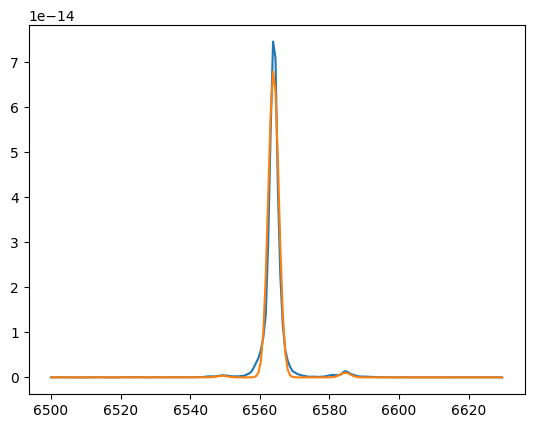

In [70]:
# Search for good initial guess

plt.plot(ha_nii.wavelength, ha_nii.flux)

ha_wav = 6564.614
niib_wav = 6549.86
niia_wav = 6585.27

ha = gaussian(ha_nii.wavelength, 2.557298e-13, ha_wav, z=-1e-4, sigma = 1.5)
niib = gaussian(ha_nii.wavelength, 2.557298e-13 * 0.005, niib_wav, z=-1e-4, sigma = 1.5)
niia = gaussian(ha_nii.wavelength, 2.557298e-13 * 0.015, niia_wav, z=-1e-4, sigma = 1.5)

plt.plot(ha_nii.wavelength, niib + ha + niia)
#plt.yscale('log')

In [71]:
params_ha_nii = Parameters()
params_ha_nii.add('z', value=-1e-4)
params_ha_nii.add('sigma', value=1.5, min=0.)
params_ha_nii.add('Ha_flux', value=3.557298e-13, min=0.)
params_ha_nii.add('Niib_to_Ha', value=0.003, min=0., max=1.)
params_ha_nii.add('Niia_to_Ha', value=0.01, min=0., max=1.)


def residual_ha_nii(params_ha_nii, x, data, uncertainty):
    
    z = params_ha_nii['z']
    sigma = params_ha_nii['sigma']
    ha_flux = params_ha_nii['Ha_flux']
    niia_flux = ha_flux * params_ha_nii['Niia_to_Ha']
    niib_flux = ha_flux * params_ha_nii['Niib_to_Ha']
    
    x = ha_nii.wavelength
    model = gaussian(x, niib_flux, niib_wav, sigma=sigma, z=z) \
          + gaussian(x, ha_flux, ha_wav, sigma=sigma, z=z) \
          + gaussian(x, niia_flux, niia_wav, sigma=sigma, z=z)
    
    return (model - ha_nii.flux) / ha_nii.noise

In [72]:
out_ha_nii = minimize(residual_ha_nii, params_ha_nii, args=(1, 1, 1),
                      method='emcee', burn=1000, steps=2500, thin=10,
                     workers=12, nwalkers=75)

100%|██████████████████████████████████████| 2500/2500 [00:17<00:00, 143.54it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 3 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 50;
tau: [ 70.54637945  44.32880167  48.95379943 155.37297538 124.39368167]


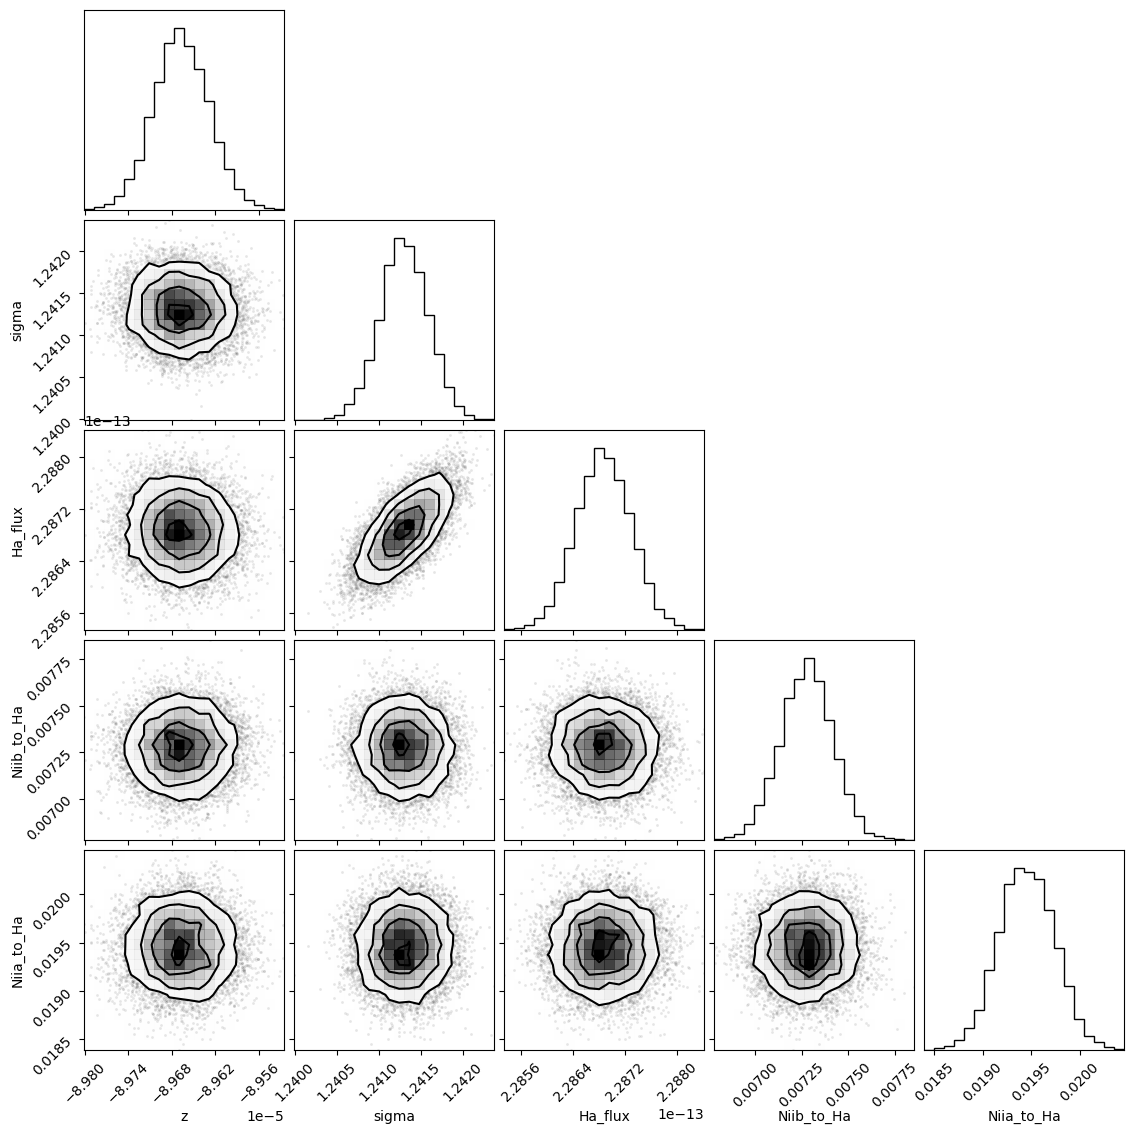

In [73]:
corner.corner(out_ha_nii.flatchain, labels=out_ha_nii.var_names);

Text(0.5, 0, '$\\lambda$ [$\\AA$]')

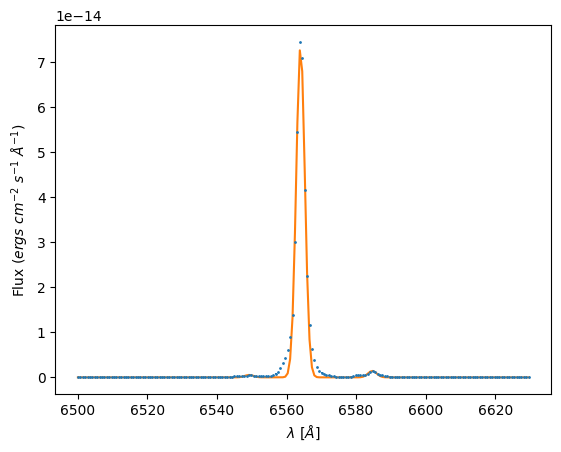

In [74]:
ha_flux = out_ha_nii.flatchain.Ha_flux.mean()
ha_std = out_ha_nii.flatchain.Ha_flux.std()

niia_flux = (ha_flux * out_ha_nii.flatchain.Niia_to_Ha).mean()
niia_std = (ha_flux * out_ha_nii.flatchain.Niia_to_Ha).std()

niib_flux = (ha_flux * out_ha_nii.flatchain.Niib_to_Ha).mean()
niib_std = (ha_flux * out_ha_nii.flatchain.Niib_to_Ha).std()

z_ha_nii = out_ha_nii.flatchain.z.mean()
sigma_ha_nii = out_ha_nii.flatchain.sigma.mean()

# Search for good initial guess
plt.errorbar(ha_nii.wavelength, ha_nii.flux, ha_nii.noise, ls='', marker='.', markersize=2, label='data')

ha = gaussian(ha_nii.wavelength, ha_flux, ha_wav, sigma=sigma_ha_nii, z=z_ha_nii)
niia = gaussian(ha_nii.wavelength, niia_flux, niia_wav, sigma=sigma_ha_nii, z=z_ha_nii)
niib = gaussian(ha_nii.wavelength, niib_flux, niib_wav, sigma=sigma_ha_nii, z=z_ha_nii)

plt.plot(ha_nii.wavelength, niia + ha + niib)
plt.ylabel(r'Flux ($ergs\ cm^{-2}\  s^{-1}\ \AA^{-1}$)')
plt.xlabel(r'$\lambda$ [$\AA$]')
#plt.yscale('log')
#plt.savefig(fname='ha_fitJ0240.jpg', bbox_inches='tight')

# Fit H$\alpha$ raw spec

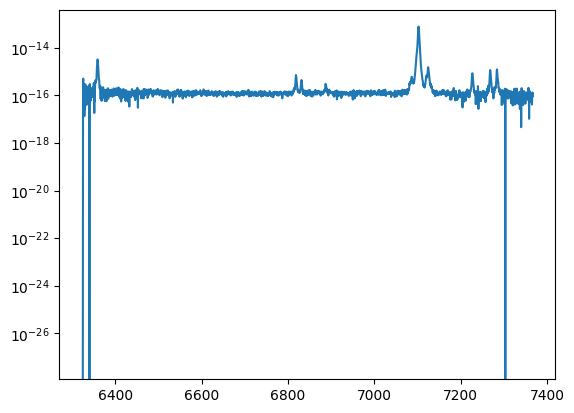

In [100]:
plt.plot(wave_ha_merged, flux_ha_merged)
plt.yscale('log')

In [101]:
# [NII]6548 + Ha + [NII]6584
select2 = (wave_ha_merged > 7050) * (wave_ha_merged < 7160)
ha_nii2 = SpecPiece('ha+nii', wave_ha_merged[select2], flux_ha_merged[select2], noise_ha_merged[select2])

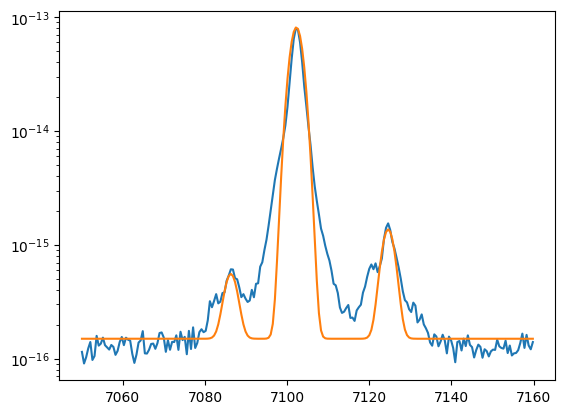

In [106]:
# Search for good initial guess

plt.plot(ha_nii2.wavelength, ha_nii2.flux)

ha_wav = 6564.614
niib_wav = 6549.86
niia_wav = 6585.27
bkg = 1.5e-16

ha = gaussian(ha_nii2.wavelength, 3.057298e-13, ha_wav, z=0.0819, sigma = 1.5)
niib = gaussian(ha_nii2.wavelength, 3.057298e-13 * 0.005, niib_wav, z=0.0819, sigma = 1.5)
niia = gaussian(ha_nii2.wavelength, 3.057298e-13 * 0.015, niia_wav, z=0.0819, sigma = 1.5)

plt.plot(ha_nii2.wavelength, bkg + niib + ha + niia)
plt.yscale('log')

In [107]:
params_ha_nii2 = Parameters()
params_ha_nii2.add('z', value=0.0819)
params_ha_nii2.add('sigma', value=1.5, min=0.)
params_ha_nii2.add('Ha_flux', value=3.057298e-13, min=0.)
params_ha_nii2.add('Niib_to_Ha', value=0.003, min=0., max=1.)
params_ha_nii2.add('Niia_to_Ha', value=0.01, min=0., max=1.)
params_ha_nii2.add('bkg', value=1.5e-16, min=0.)


def residual_ha_nii2(params_ha_nii2, x, data, uncertainty):
    
    z = params_ha_nii2['z']
    sigma = params_ha_nii2['sigma']
    ha_flux = params_ha_nii2['Ha_flux']
    niia_flux = ha_flux * params_ha_nii2['Niia_to_Ha']
    niib_flux = ha_flux * params_ha_nii2['Niib_to_Ha']
    bkg = params_ha_nii2['bkg']
    
    x = ha_nii2.wavelength
    model = gaussian(x, niib_flux, niib_wav, sigma=sigma, z=z) \
          + gaussian(x, ha_flux, ha_wav, sigma=sigma, z=z) \
          + gaussian(x, niia_flux, niia_wav, sigma=sigma, z=z)
    
    return (model + bkg - ha_nii2.flux) / ha_nii2.noise

In [108]:
out_ha_nii2 = minimize(residual_ha_nii2, params_ha_nii2, args=(1, 1, 1),
                      method='emcee', burn=1000, steps=2500, thin=10,
                     workers=12, nwalkers=75)

100%|██████████████████████████████████████| 2500/2500 [00:18<00:00, 135.00it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 4 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 50;
tau: [ 30.18090483  32.96734218  81.68630675 179.75605928 114.4150878
 108.70859901]


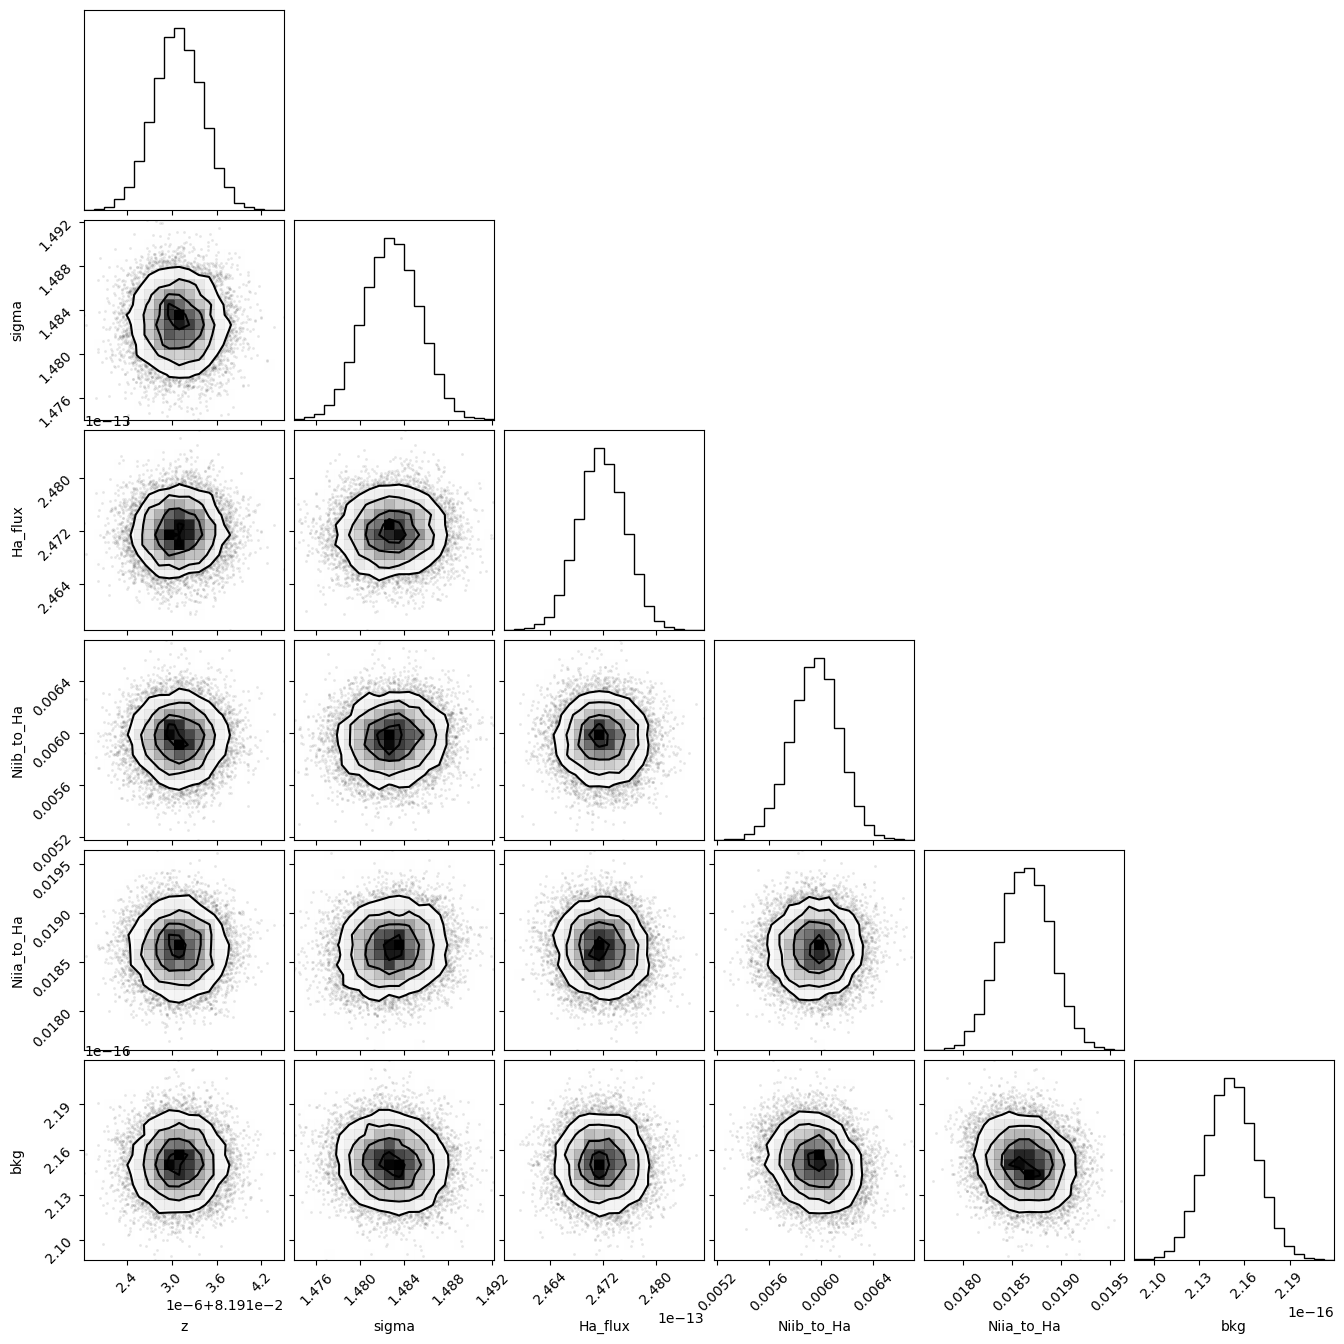

In [110]:
corner.corner(out_ha_nii2.flatchain, labels=out_ha_nii2.var_names);

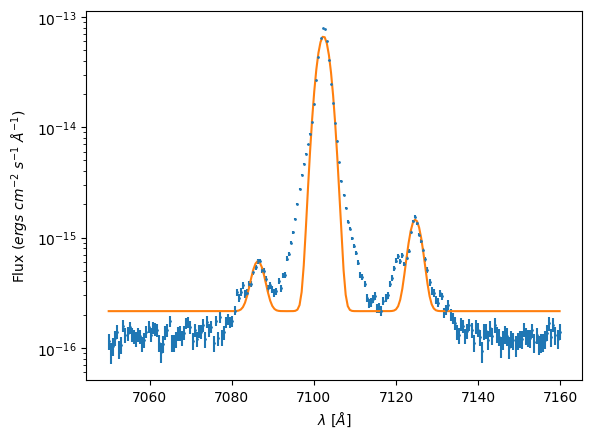

In [115]:
ha_flux2 = out_ha_nii2.flatchain.Ha_flux.mean()
ha_std2 = out_ha_nii2.flatchain.Ha_flux.std()

niia_flux2 = (ha_flux2 * out_ha_nii2.flatchain.Niia_to_Ha).mean()
niia_std2 = (ha_flux2 * out_ha_nii2.flatchain.Niia_to_Ha).std()

niib_flux2 = (ha_flux2 * out_ha_nii2.flatchain.Niib_to_Ha).mean()
niib_std2 = (ha_flux2 * out_ha_nii2.flatchain.Niib_to_Ha).std()

bkg_ha_nii2 = out_ha_nii2.flatchain.bkg.mean()
z_ha_nii2 = out_ha_nii2.flatchain.z.mean()
sigma_ha_nii2 = out_ha_nii2.flatchain.sigma.mean()

# Search for good initial guess
plt.errorbar(ha_nii2.wavelength, ha_nii2.flux, ha_nii2.noise, ls='', marker='.', markersize=2, label='data')

ha = gaussian(ha_nii2.wavelength, ha_flux2, ha_wav, sigma=sigma_ha_nii2, z=z_ha_nii2)
niia = gaussian(ha_nii2.wavelength, niia_flux2, niia_wav, sigma=sigma_ha_nii2, z=z_ha_nii2)
niib = gaussian(ha_nii2.wavelength, niib_flux2, niib_wav, sigma=sigma_ha_nii2, z=z_ha_nii2)

plt.plot(ha_nii2.wavelength, bkg_ha_nii2 + niia + ha + niib)
plt.ylabel(r'Flux ($ergs\ cm^{-2}\  s^{-1}\ \AA^{-1}$)')
plt.xlabel(r'$\lambda$ [$\AA$]')
plt.yscale('log')
#plt.savefig(fname='ha_fitJ0240.jpg', bbox_inches='tight')

In [137]:
niib_flux

2.688553548670442e-15

In [138]:
niib_flux2

1.4720664065266075e-15

In [128]:
(np.abs(ha_flux2 - ha_flux) / ha_flux2)*100

7.483029005865986

In [129]:
(np.abs(niia_flux2 - niia_flux) / niia_flux2)*100

3.430684570419529

In [130]:
(np.abs(niib_flux2 - niib_flux) / niib_flux2)*100

82.63806148624631

In [133]:
niib_flux2

1.4720664065266075e-15

In [139]:
import uncertainties as unc

In [144]:
ha = unc.ufloat(ha_flux, ha_std)
ha2 = unc.ufloat(ha_flux2, ha_std2)

niia = unc.ufloat(niia_flux, niia_std)
niia2 = unc.ufloat(niia_flux2, niia_std2)

niib = unc.ufloat(niib_flux, niib_std)
niib2 = unc.ufloat(niib_flux2, niib_std2)

In [147]:
100 * np.abs(niia/ha - niia2/ha2) / (niia/ha)

4.196306474183788+/-1.9377814083730547

In [146]:
niia2/ha2

0.018637518849957648+/-0.00025904175934497573